In [1]:
try:
    from notebooks.bootstrap import ensure_src_importable
except ModuleNotFoundError:
    from bootstrap import ensure_src_importable

ensure_src_importable()


PosixPath('/Users/caiogimenes/projects/river-evaluate')

In [2]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from src.paths import resolve_repo_path
from src.utils import rank_logs
from src.stats import friedman_statistics, iman_davenport, eval_significance, critical_difference_nemenyi, critical_difference_bonferroni_dunn
from src.plot import draw_nemenyi_diagram, draw_bonferroni_dunn_diagram

In [3]:
with open(resolve_repo_path("logs/gradual.pkl"), "rb") as file:
    logs = pickle.load(file)

In [4]:
models = {log.model: 0 for log in logs}
synth_datasets = {log.dataset: 0 for log in logs}
N_MODELS = len(models)
N_DATASETS = len(synth_datasets)
print(f"""
MODELS: {N_MODELS}
N_DATASETS: {N_DATASETS}
""")


MODELS: 6
N_DATASETS: 33



In [5]:
params = ["performance", "memory", "time"]
results = []
for param in params:
    friedman_matrix = rank_logs(logs, param, models.keys(), synth_datasets.keys())
    results.append(friedman_matrix.rank(axis=1, ascending=True, method="average").mean())

results = pd.DataFrame(results, index=params)
stats_results = results.copy()
stats_results["fried_stats"] = results.apply(lambda x: friedman_statistics(x, N_DATASETS), axis=1)
stats_results["iman_davenport"] = stats_results["fried_stats"].apply(lambda x: iman_davenport(x, N_DATASETS, N_MODELS))
stats_results["significant"] = stats_results["iman_davenport"].apply(lambda x: eval_significance(x, N_MODELS, N_DATASETS, 0.05))

In [6]:
rank_logs(logs, "time", models.keys(), synth_datasets.keys())/1e6

,HATR (baseline),HTR-QO-0.25 (baseline),HTR-QO-0.5 (baseline),HTR-AQO-Triangular,HTR-AQO-Epanechnikov,HTR-AQO-Smooth
\n RandomRBF\n Seed Model = 168\n Seed Sample = 159\n N of classes: 2\n Change Speed: 0.3\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,8.588251,62.493695,39.733697,5.627599,5.716447,6.166519
\n RandomRBF\n Seed Model = 575\n Seed Sample = 380\n N of classes: 2\n Change Speed: 0.1\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,18.001557,50.424156,40.460836,7.083447,4.659850,7.893348
\n RandomRBF\n Seed Model = 386\n Seed Sample = 194\n N of classes: 2\n Change Speed: 0.2\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,2.120984,61.181623,36.931316,4.034301,4.667547,4.674828
\n RandomRBF\n Seed Model = 370\n Seed Sample = 730\n N of classes: 2\n Change Speed: 0.3\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,0.490728,50.588315,37.669522,11.428345,9.376108,8.683588
\n RandomRBF\n Seed Model = 489\n Seed Sample = 785\n N of classes: 2\n Change Speed: 0.3\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,13.982808,50.470473,41.107783,7.664454,6.444818,7.374338
\n RandomRBF\n Seed Model = 21\n Seed Sample = 711\n N of classes: 2\n Change Speed: 0.3\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,8.746141,50.893467,39.548279,4.969353,4.289972,4.043737
\n RandomRBF\n Seed Model = 862\n Seed Sample = 107\n N of classes: 2\n Change Speed: 0.2\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,5.631386,50.921018,38.217998,6.737697,5.426604,7.254737
\n RandomRBF\n Seed Model = 65\n Seed Sample = 644\n N of classes: 2\n Change Speed: 0.1\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,10.783295,49.718858,38.063303,7.911645,6.111119,6.423334
\n RandomRBF\n Seed Model = 324\n Seed Sample = 577\n N of classes: 2\n Change Speed: 0.1\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,37.387685,49.762000,38.165212,6.789873,7.048989,9.954299
\n RandomRBF\n Seed Model = 816\n Seed Sample = 417\n N of classes: 2\n Change Speed: 0.3\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,2.590031,47.477581,39.785450,10.664970,10.169184,7.162515


In [7]:
stats_results

,HATR (baseline),HTR-QO-0.25 (baseline),HTR-QO-0.5 (baseline),HTR-AQO-Triangular,HTR-AQO-Epanechnikov,HTR-AQO-Smooth,fried_stats,iman_davenport,significant
performance,5.030303,3.848485,3.030303,3.696970,2.878788,2.515152,38.454545,9.724138,True
memory,2.242424,5.939394,4.424242,2.242424,2.818182,3.333333,98.627706,47.551265,True
time,2.333333,5.484848,4.515152,2.242424,3.030303,3.393939,76.792208,27.858657,True


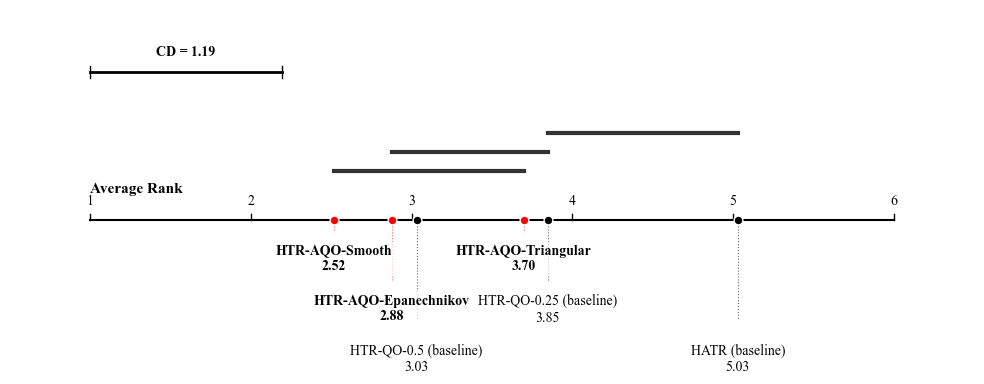

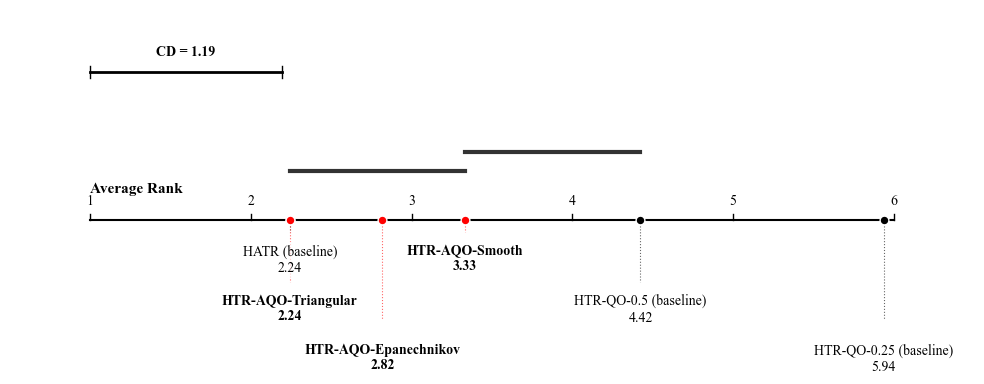

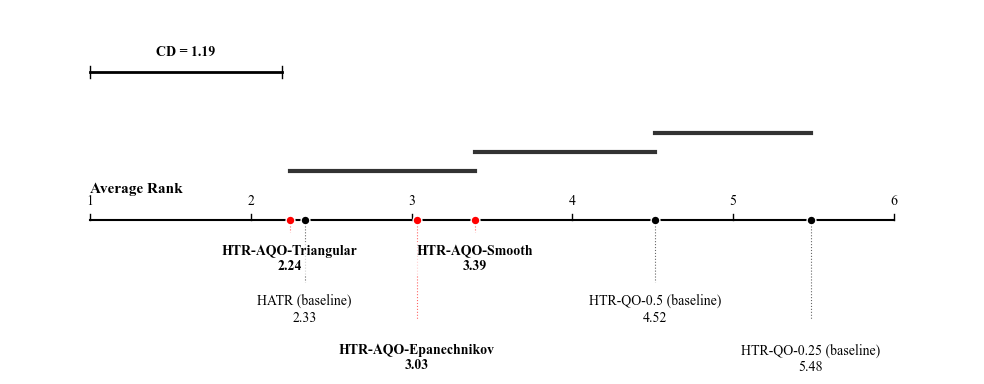

In [8]:
cd = critical_difference_nemenyi(N_MODELS, N_DATASETS, significance=0.1)
for param in params:
    fig = draw_nemenyi_diagram(results.loc[param], cd)
    plt.savefig(resolve_repo_path(f"output/{param.upper()}.png"), dpi=300, bbox_inches="tight")
    plt.show()

In [9]:
from src.plot import Plots

/var/folders/hl/yd970xq97311qs2ngf2mhb1m0000gn/T/ipykernel_16607/4079137102.py:2: DeprecationWarning: Plots.plot_all is deprecated; use Plots.export
  plotter.plot_all(logs)


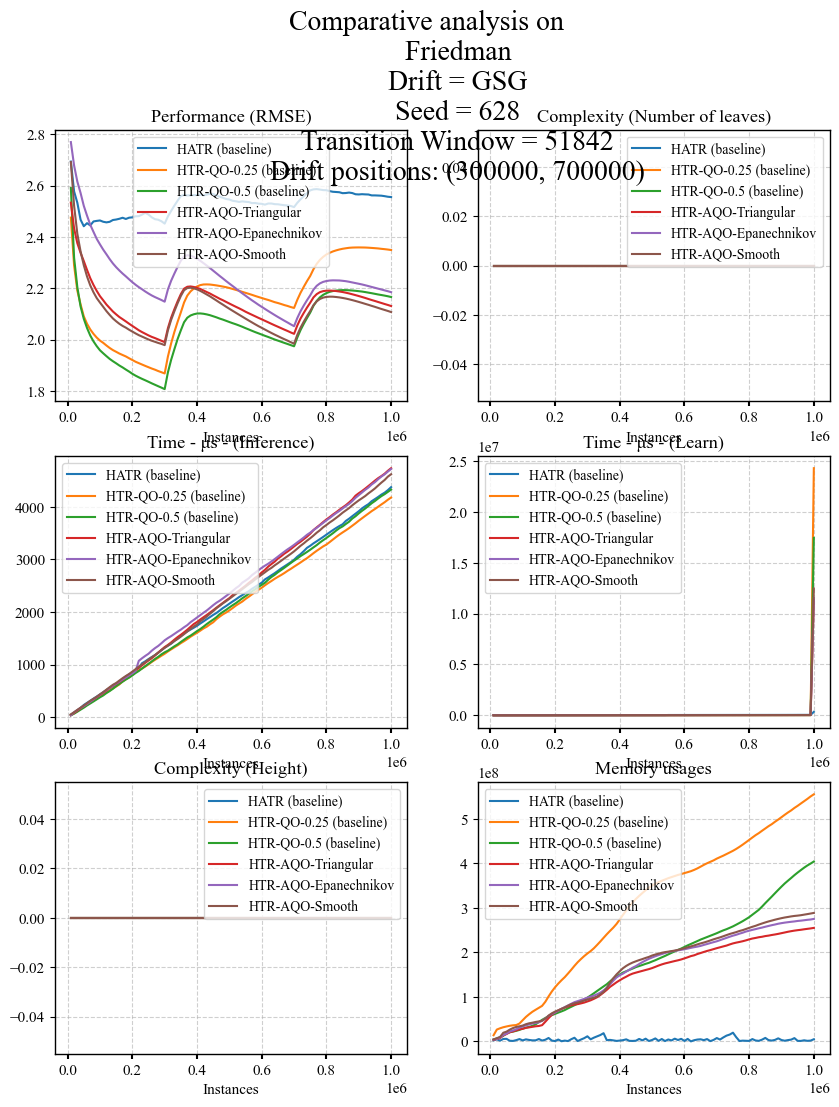

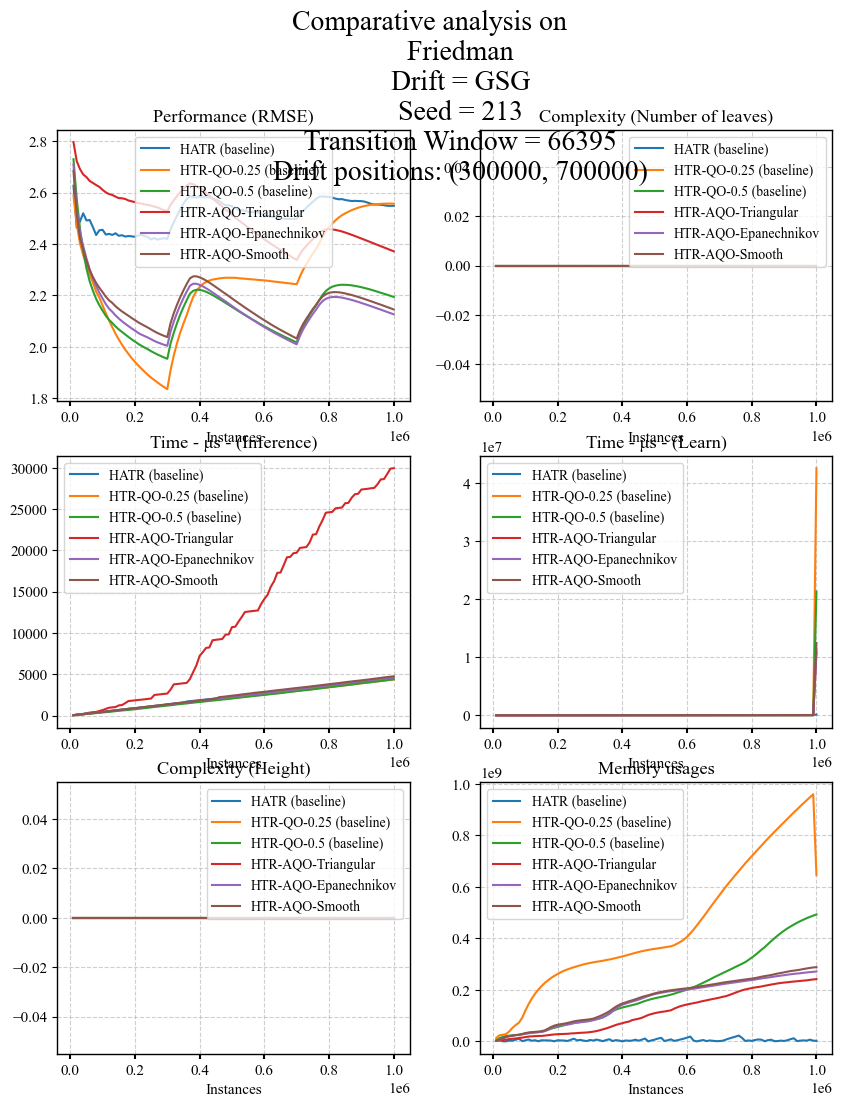

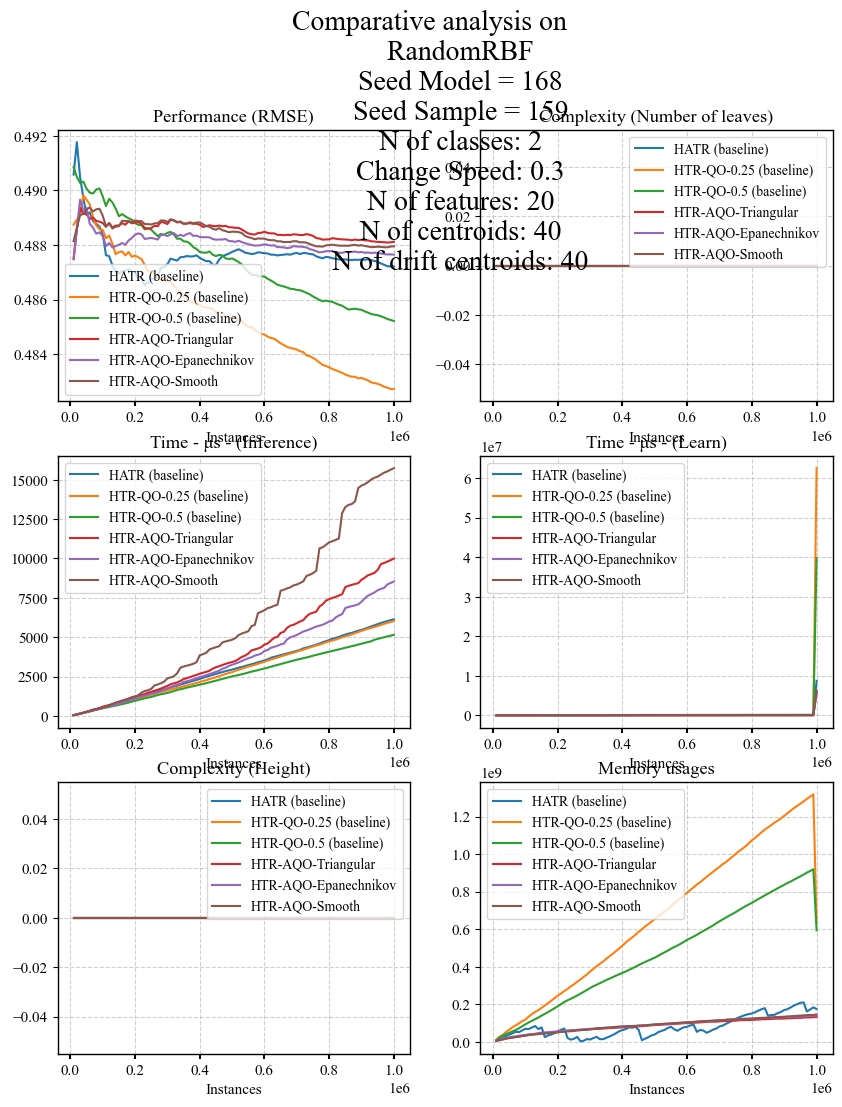

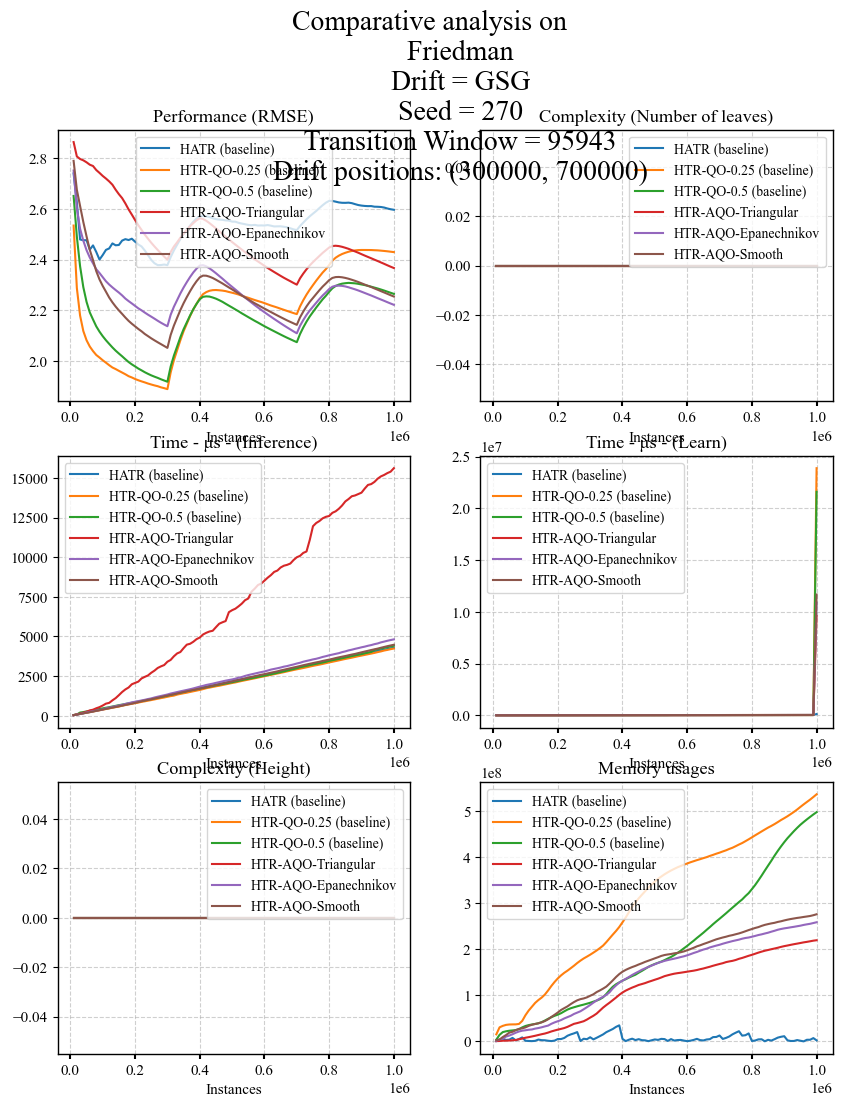

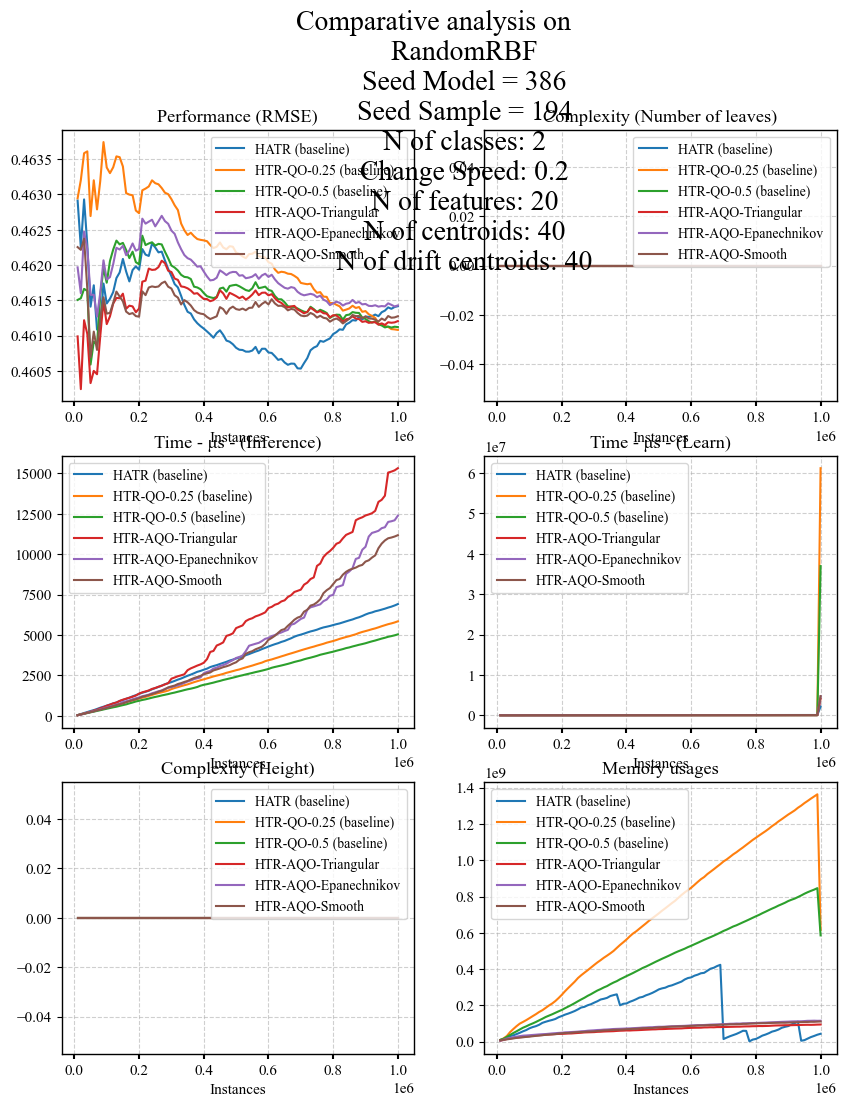

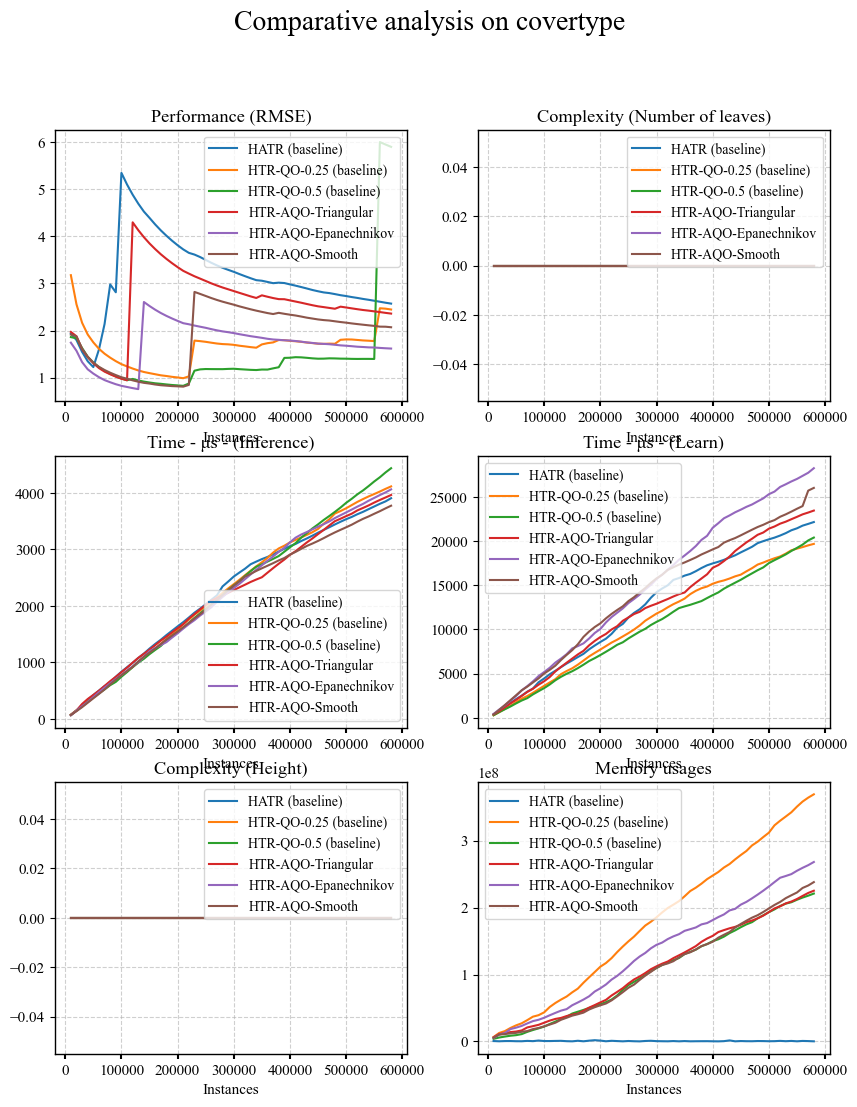

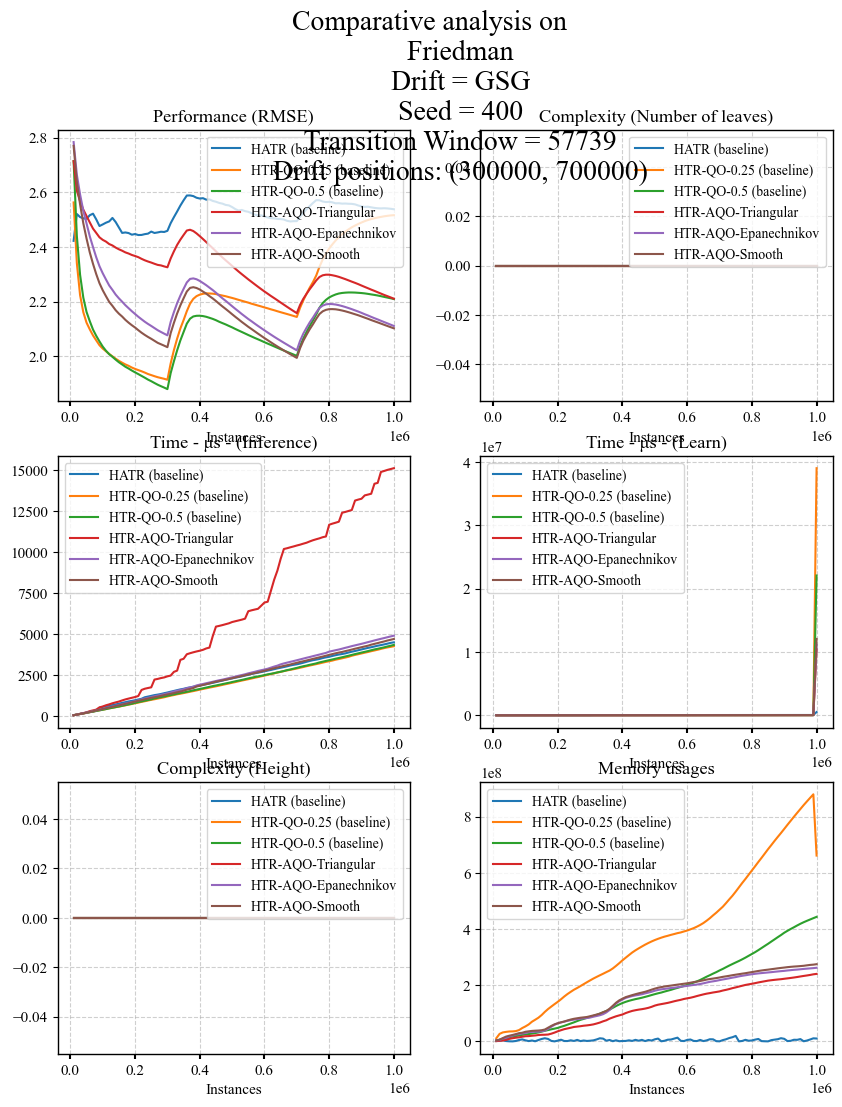

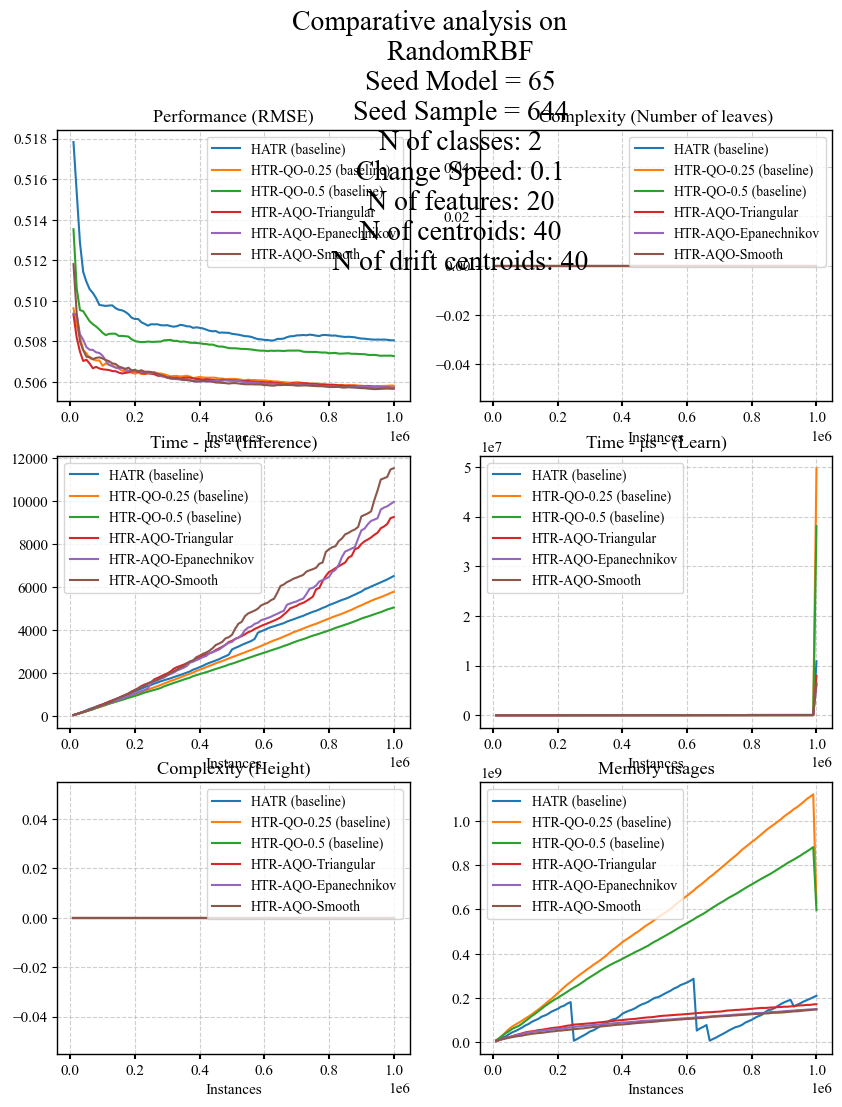

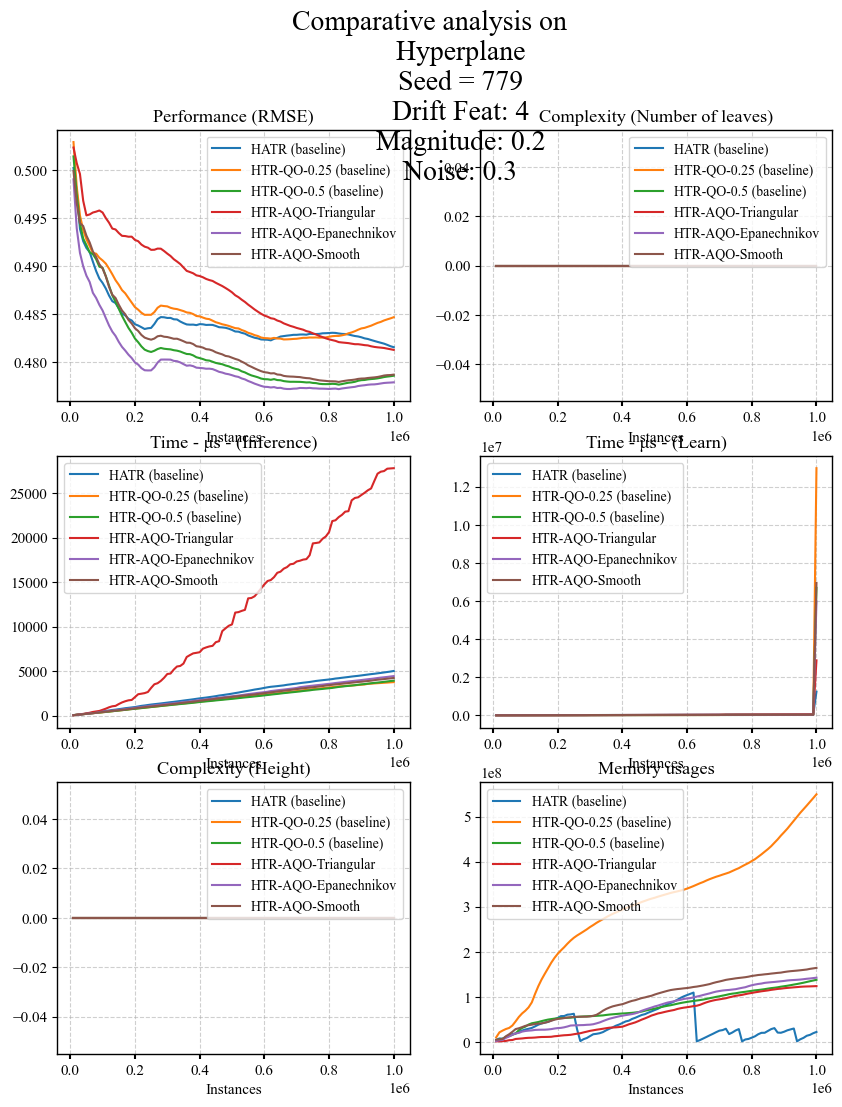

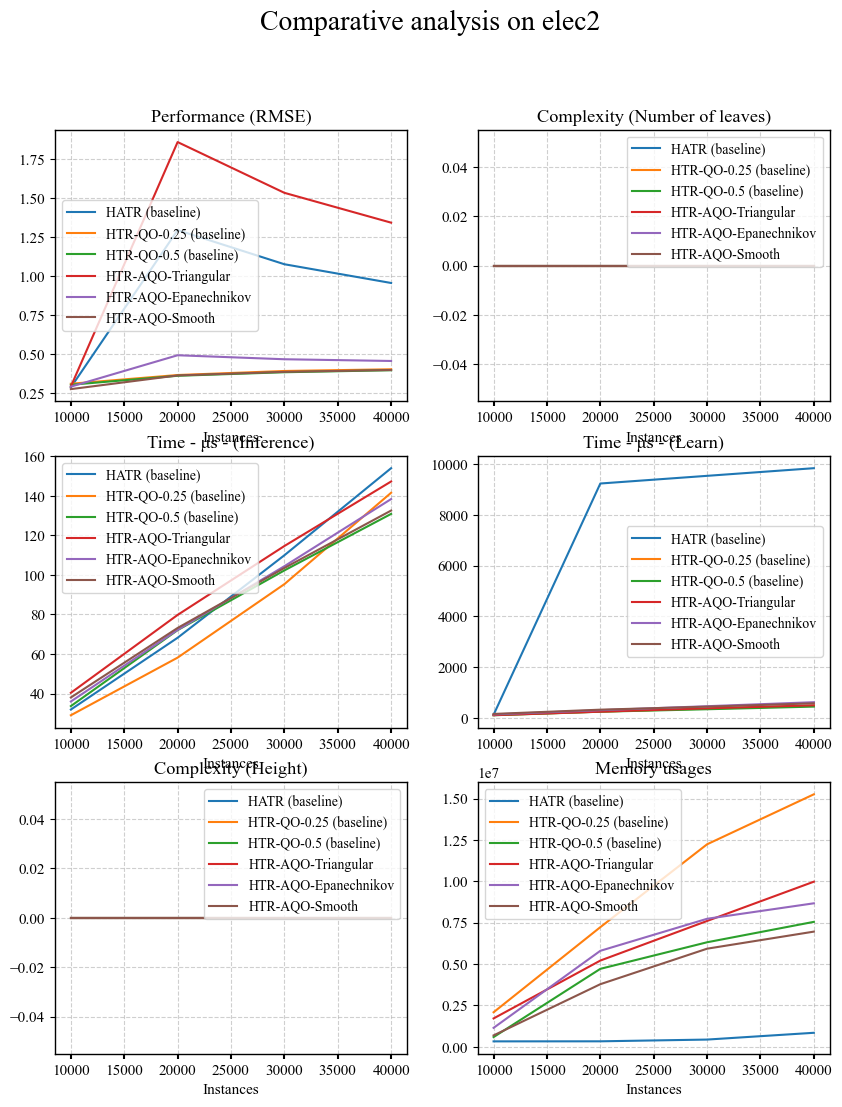

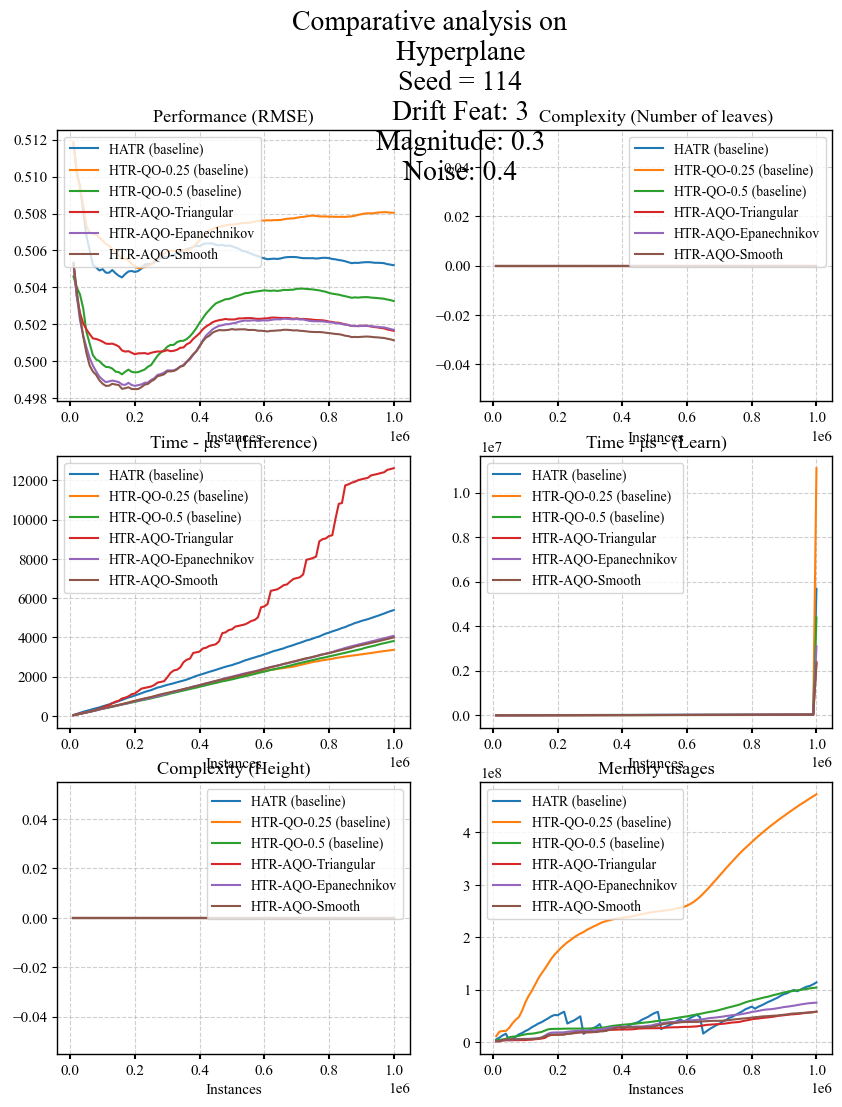

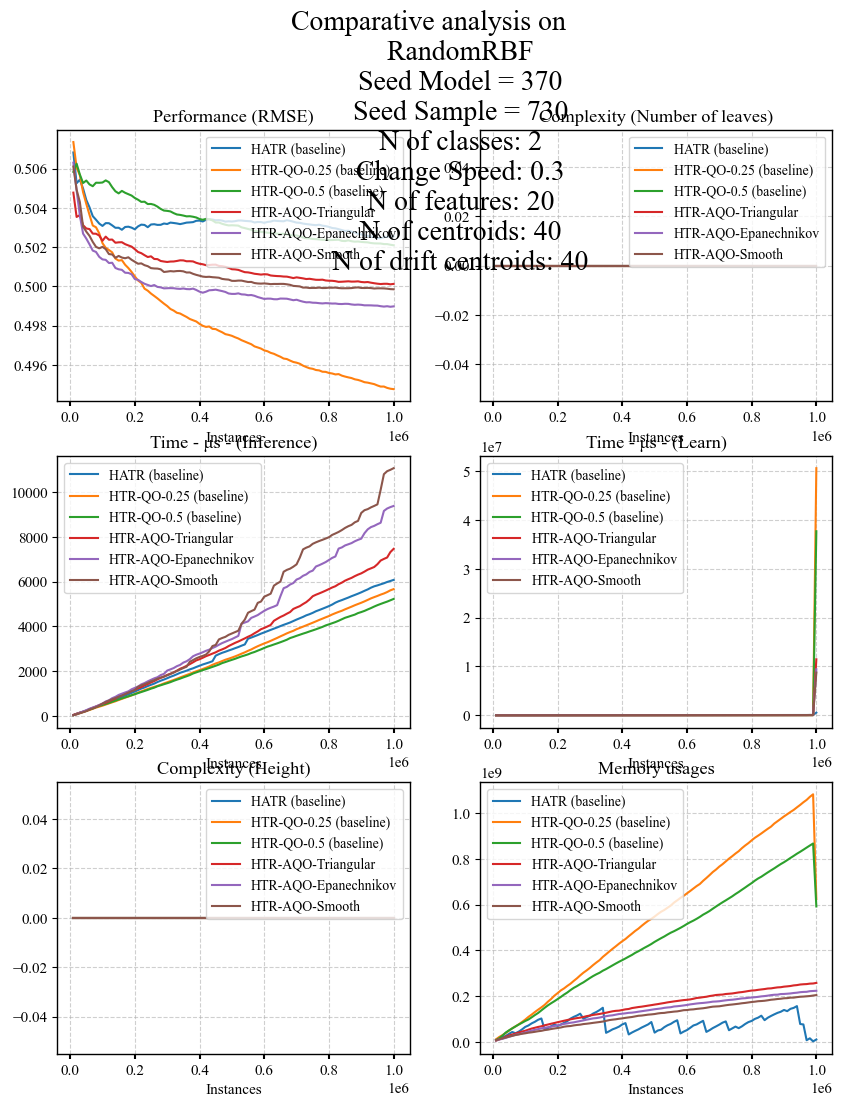

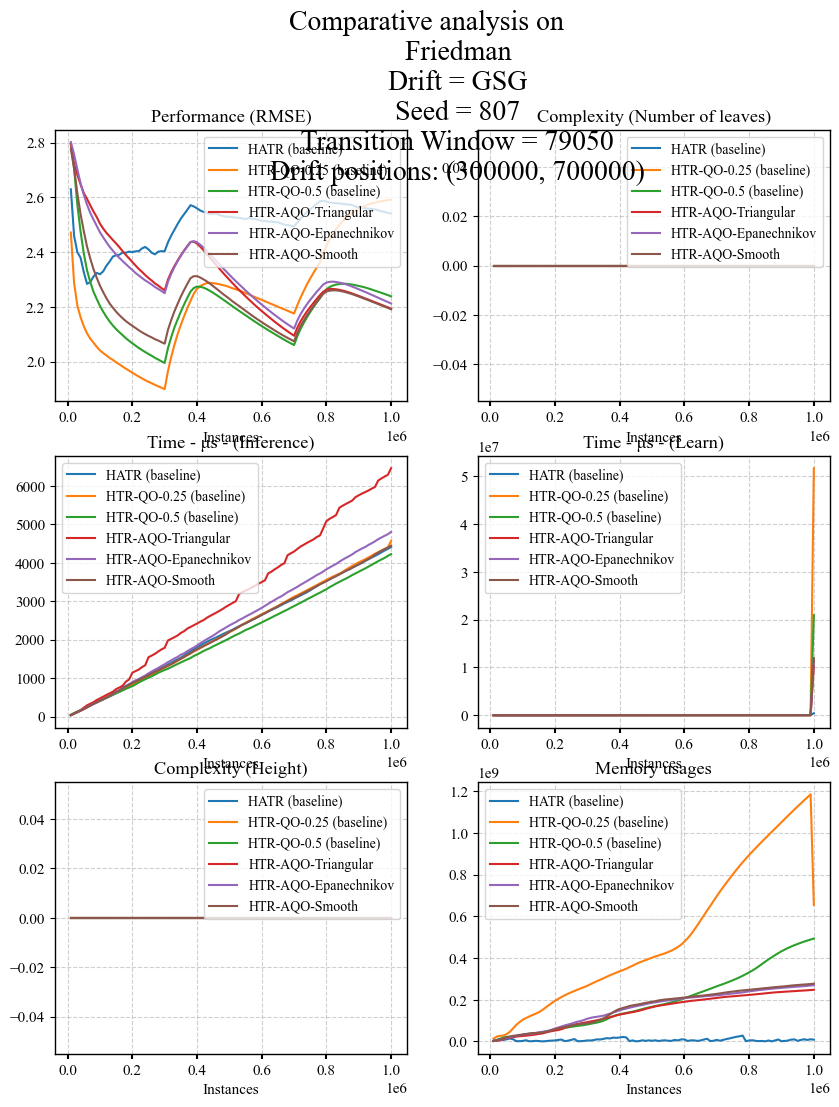

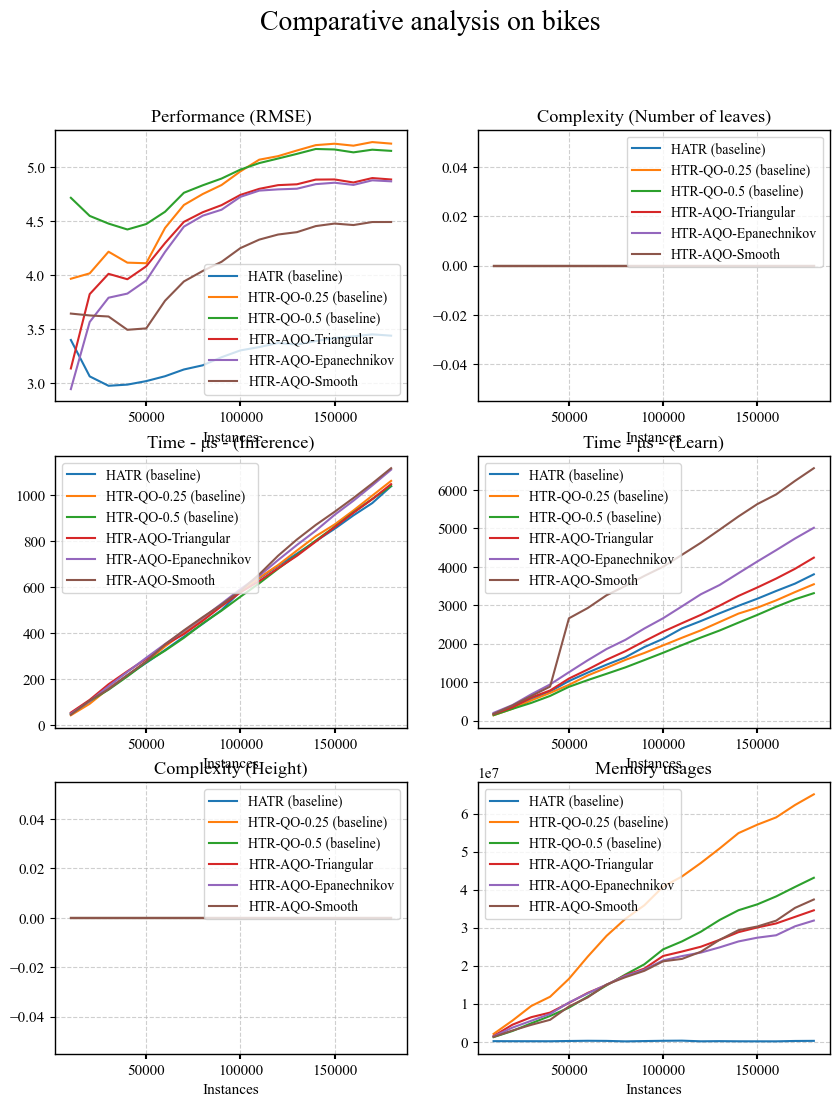

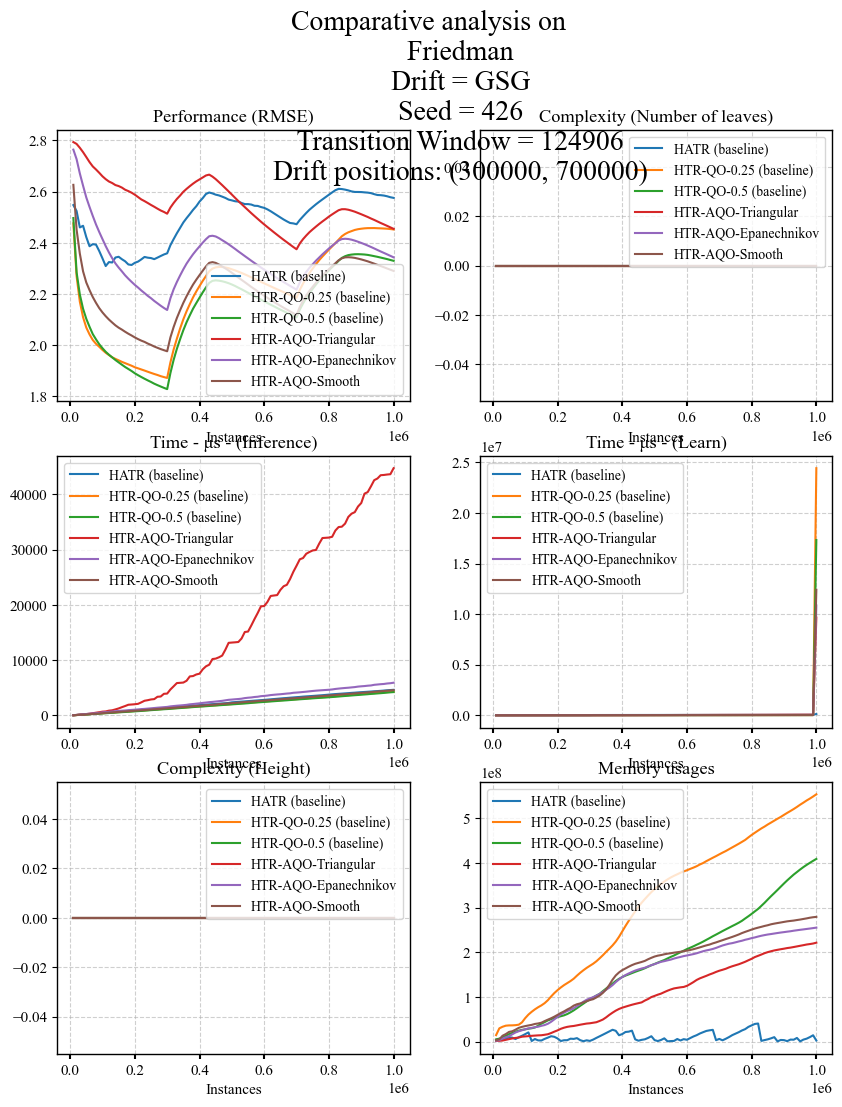

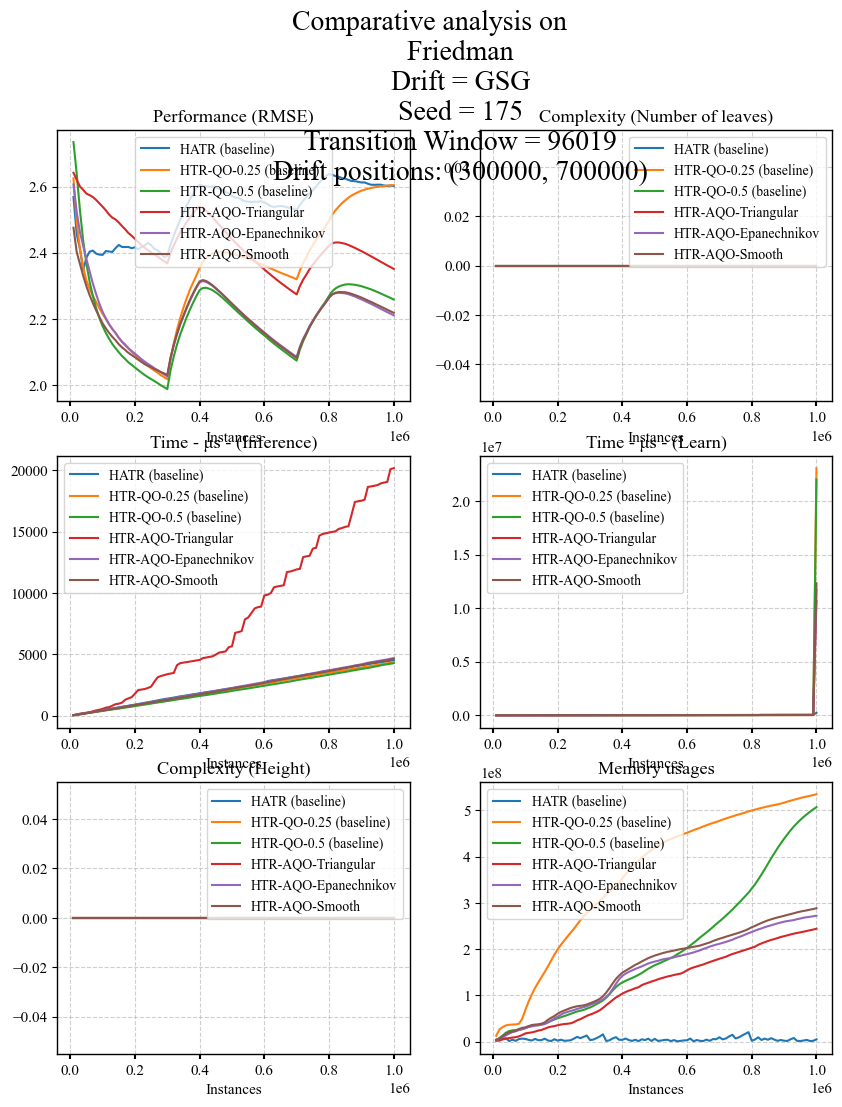

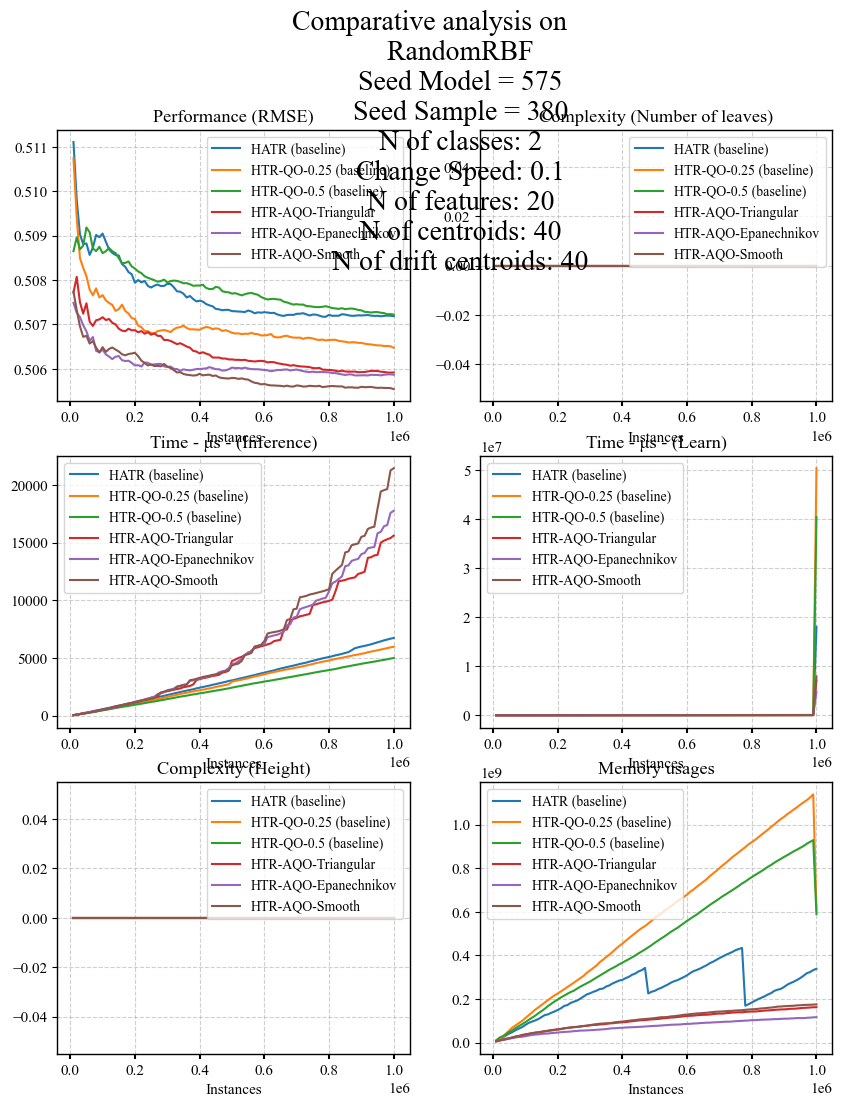

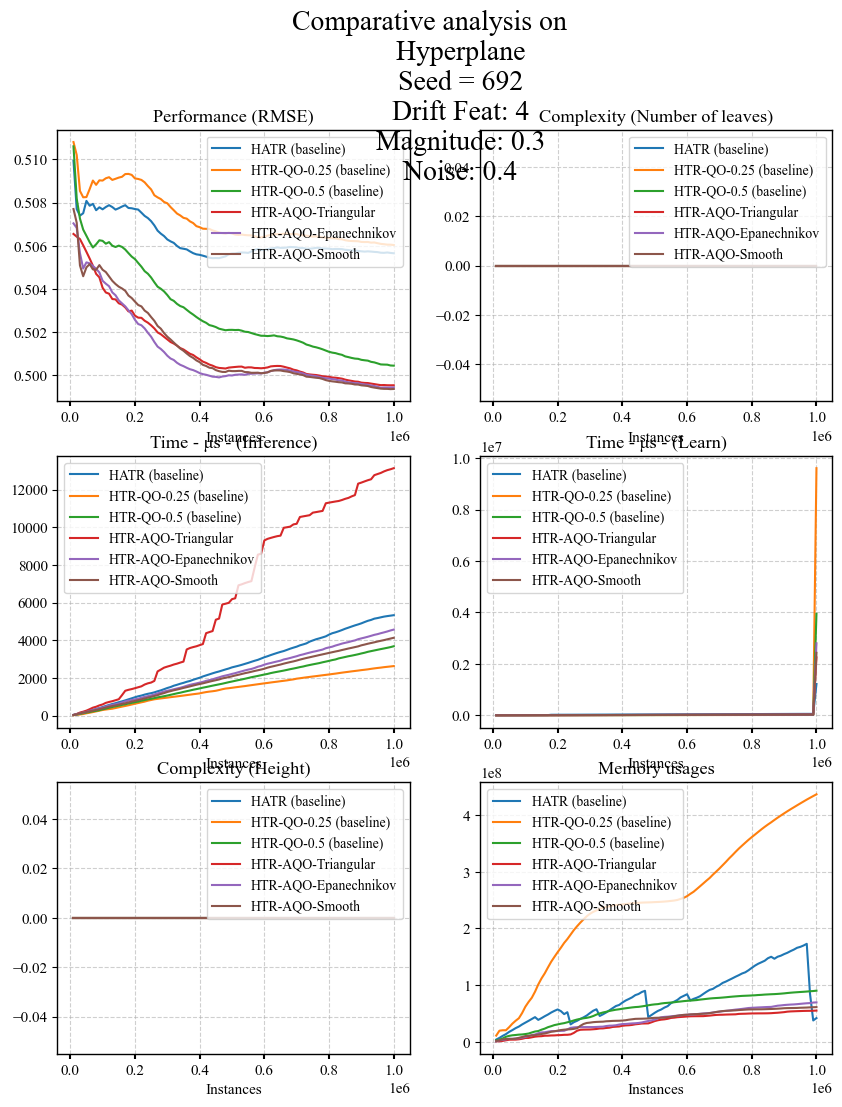

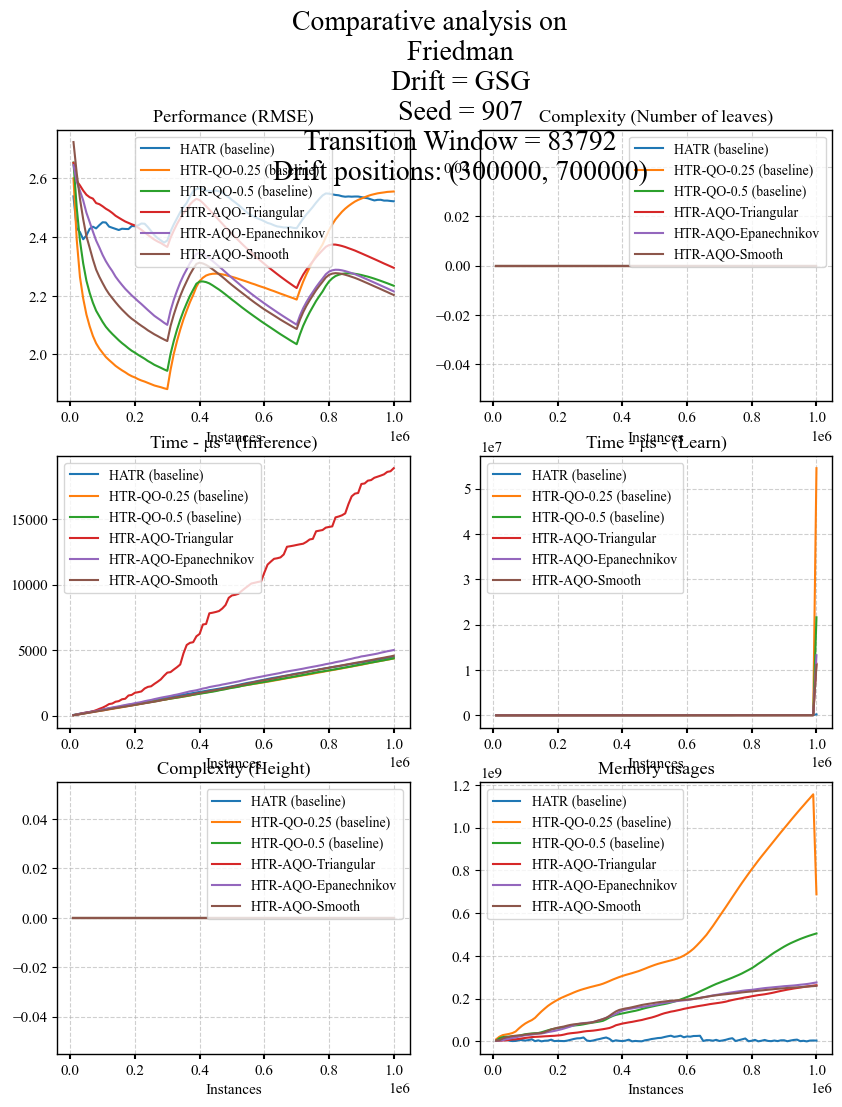

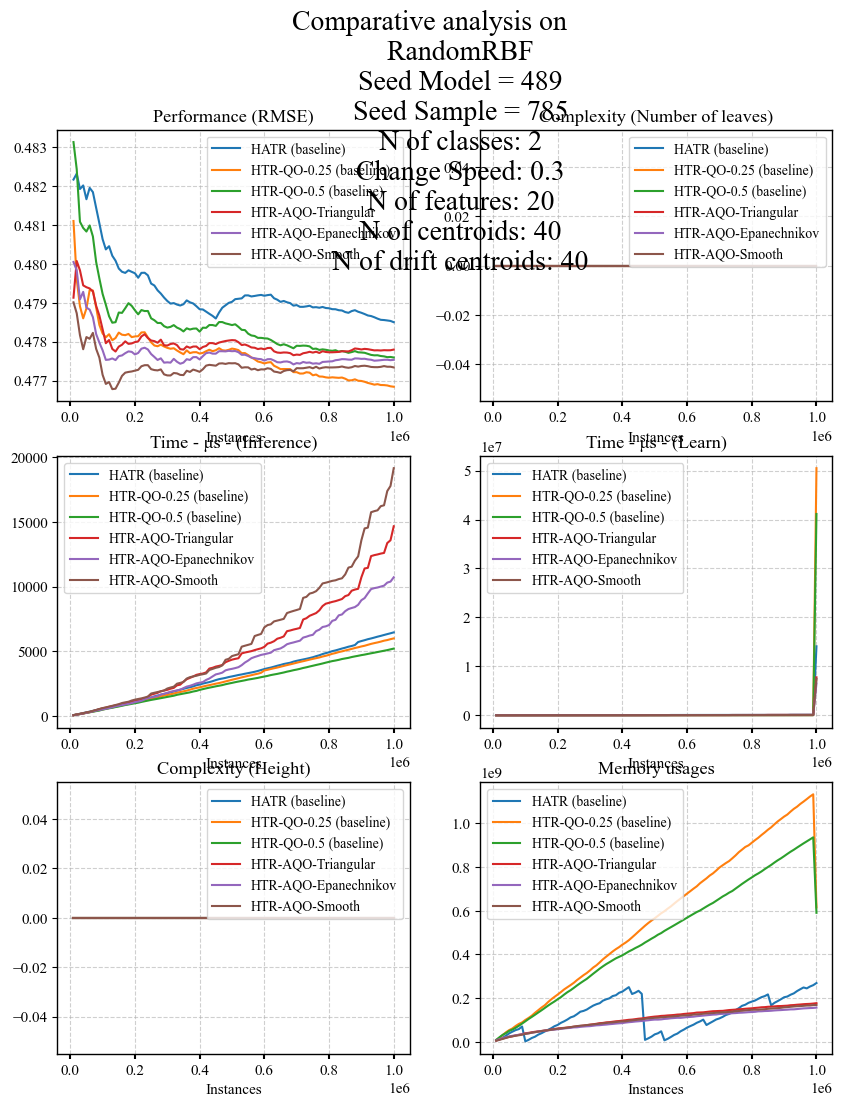

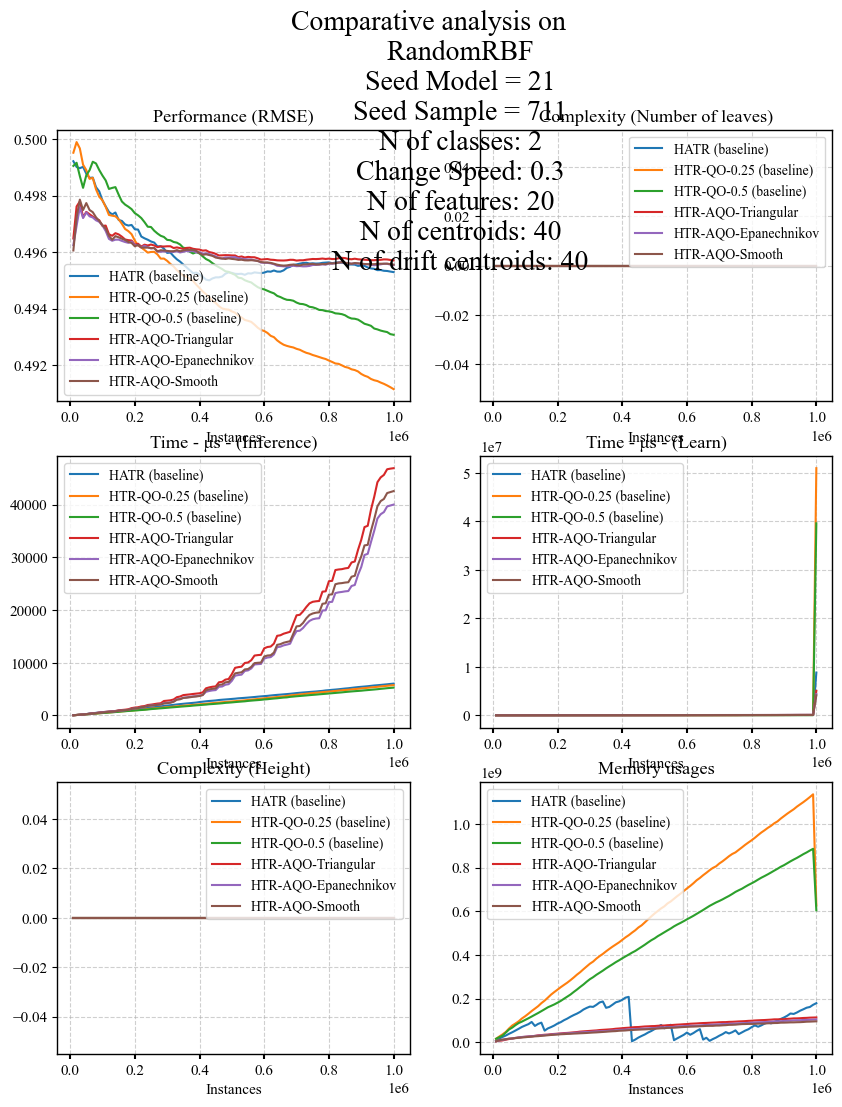

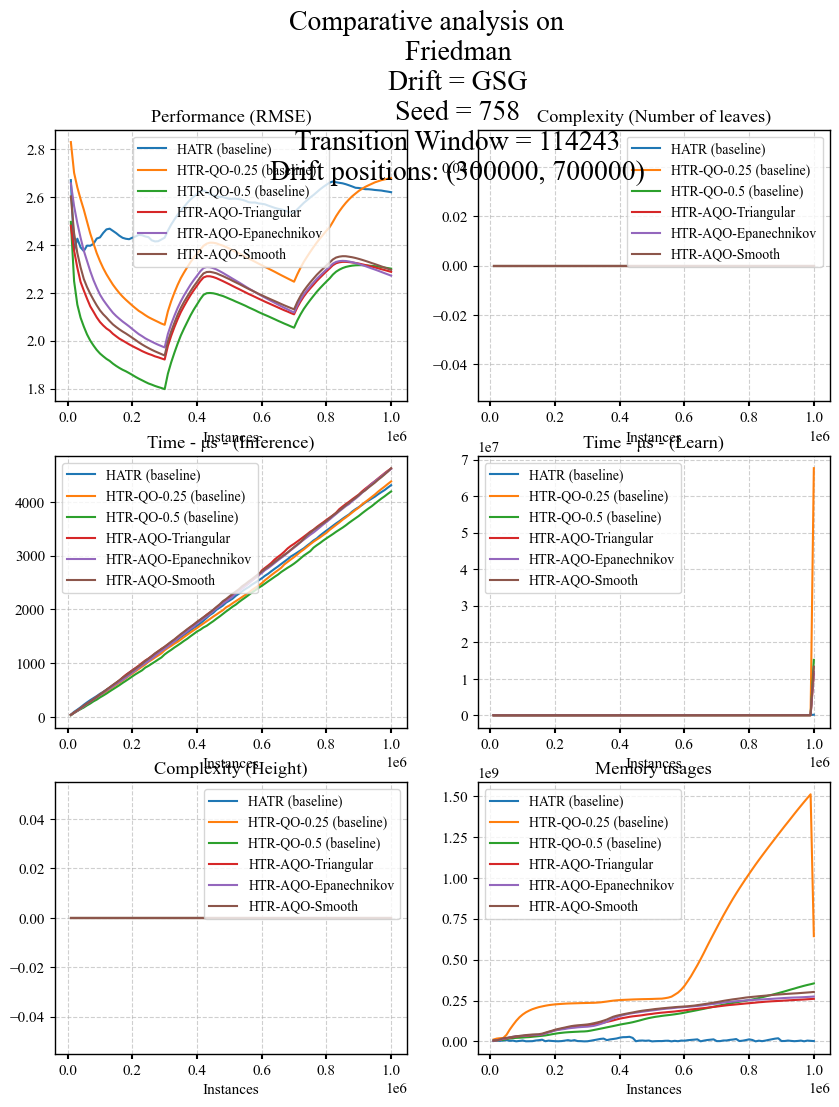

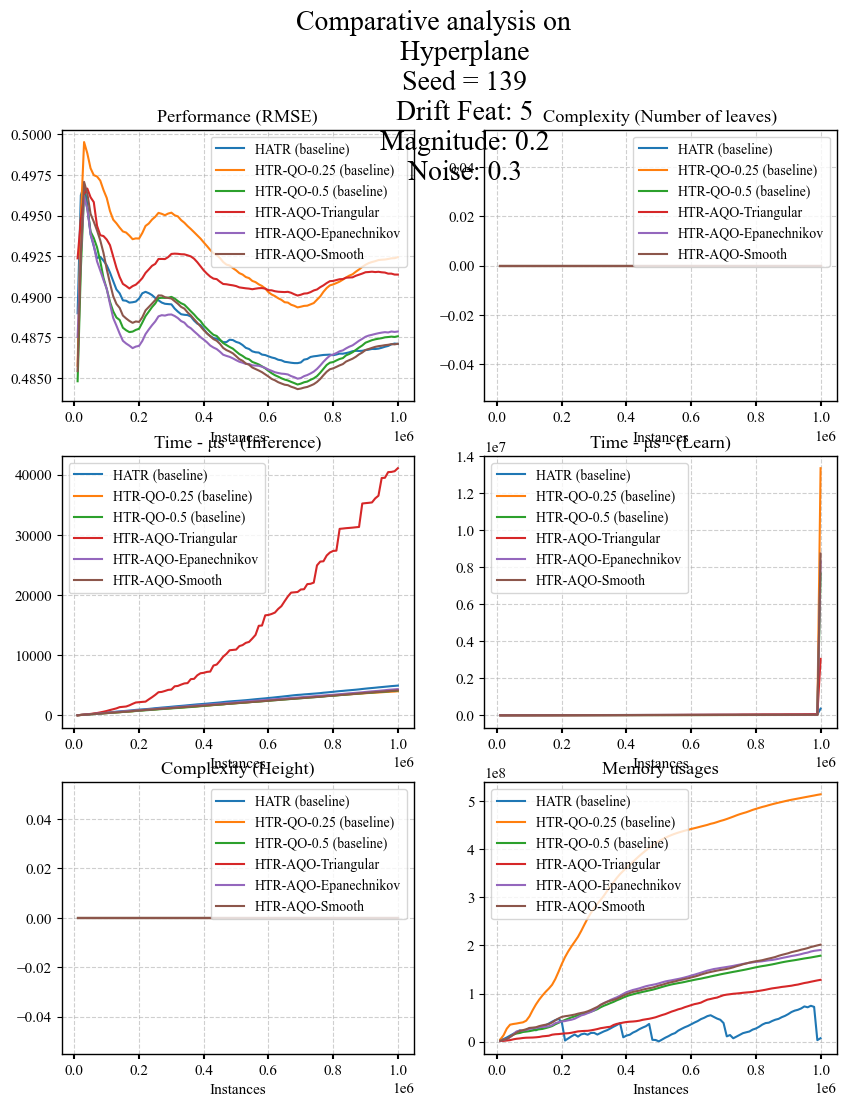

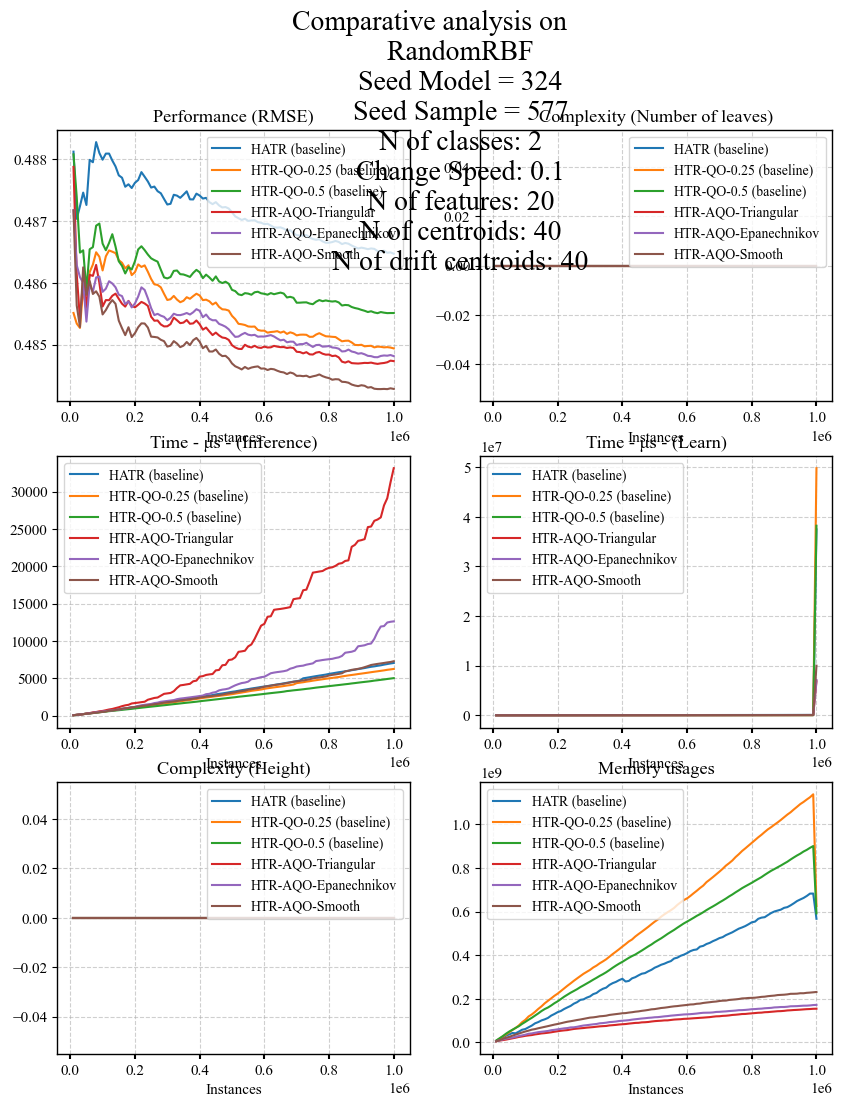

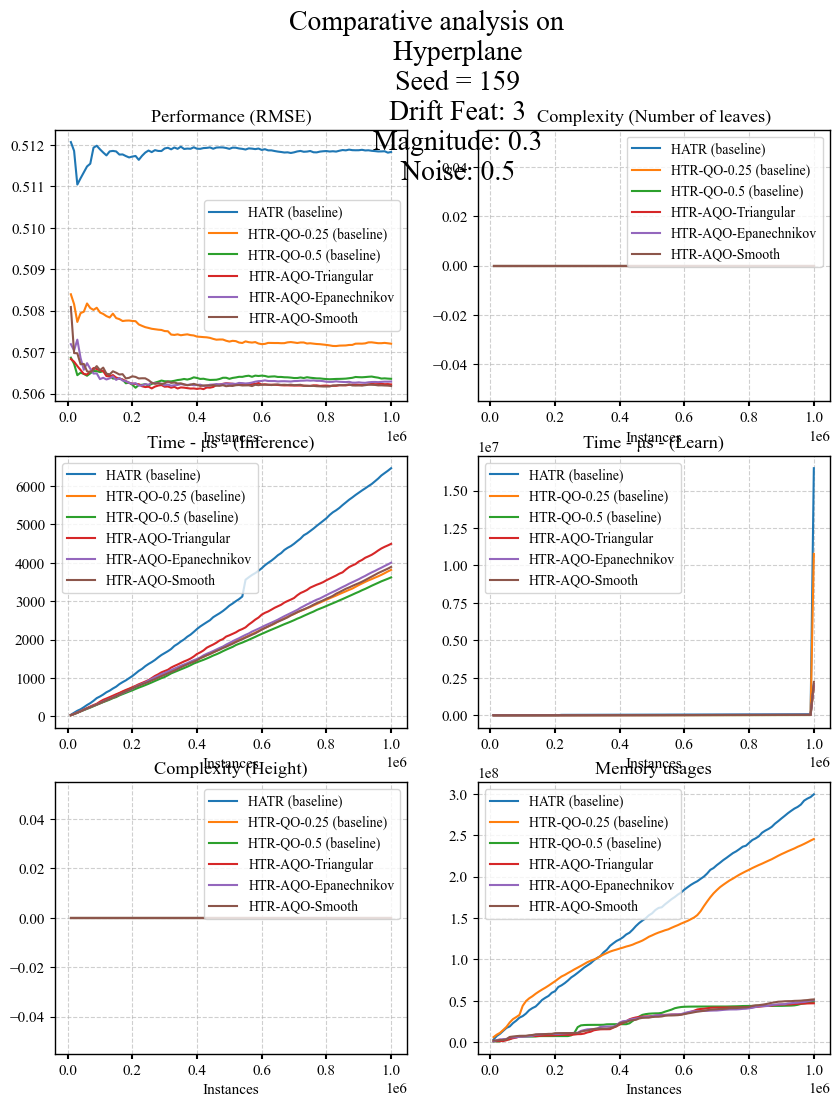

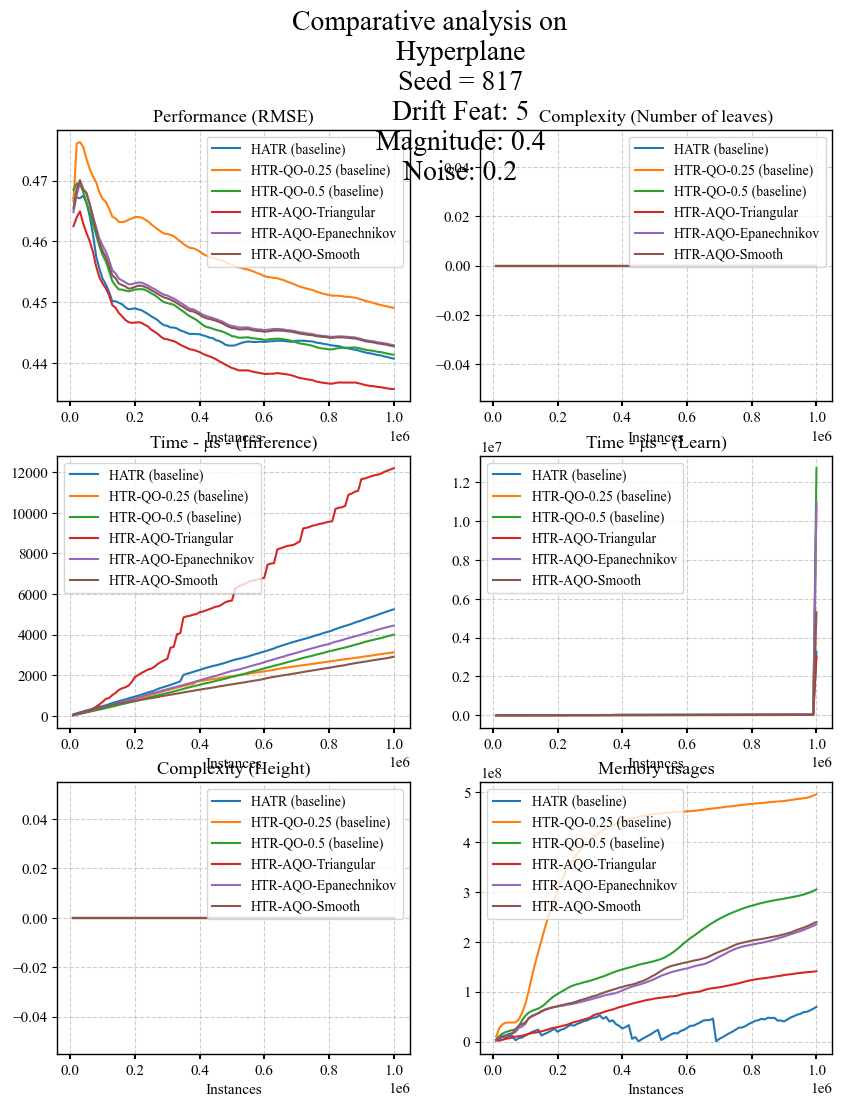

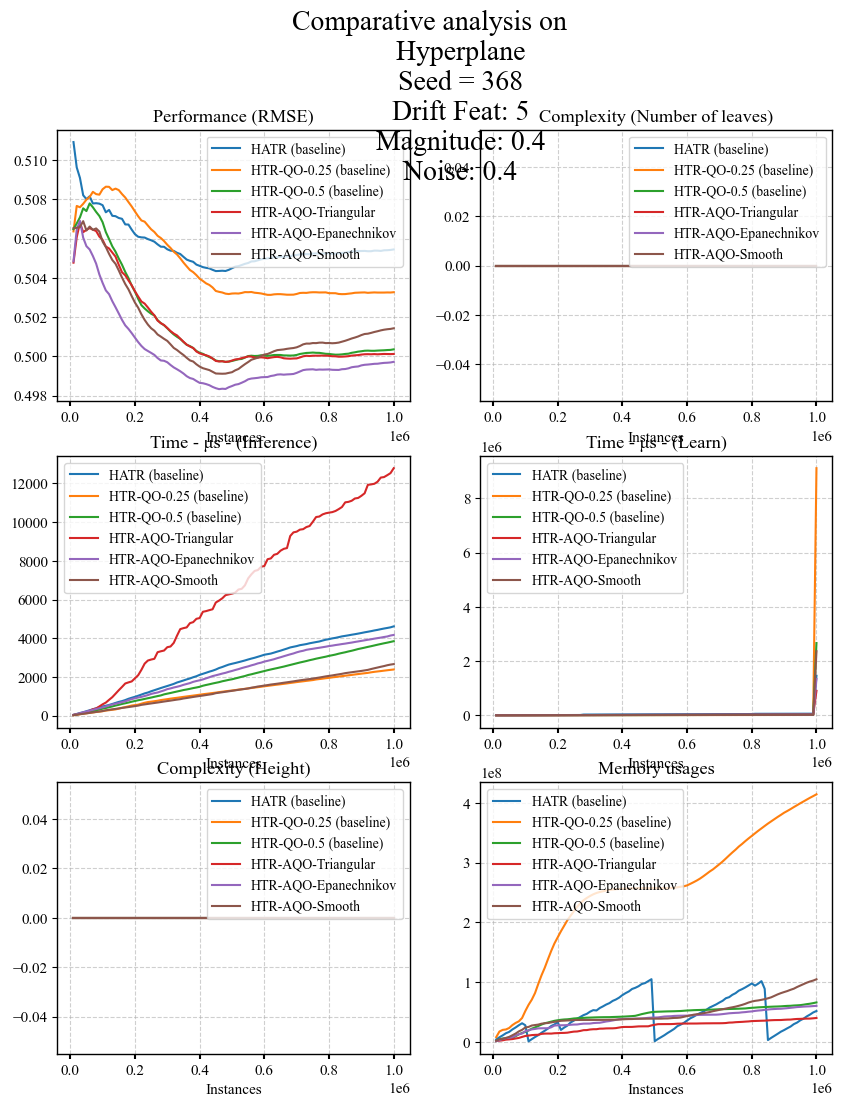

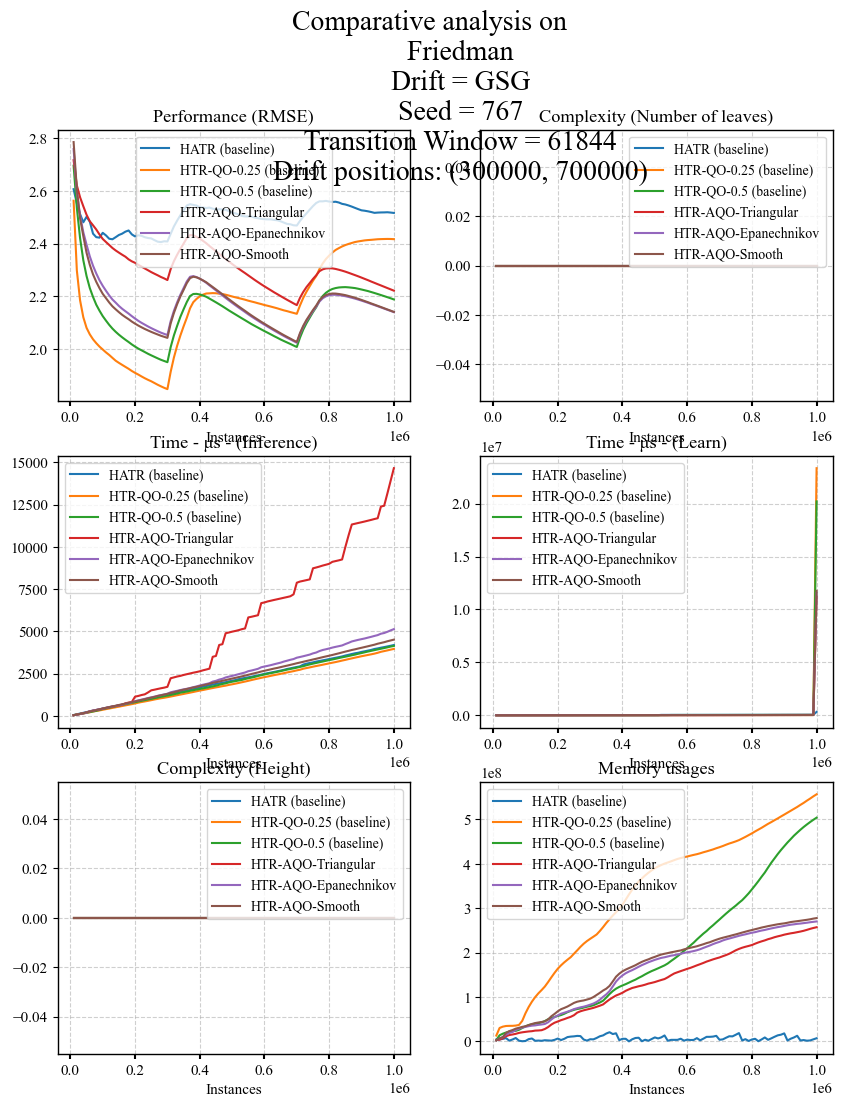

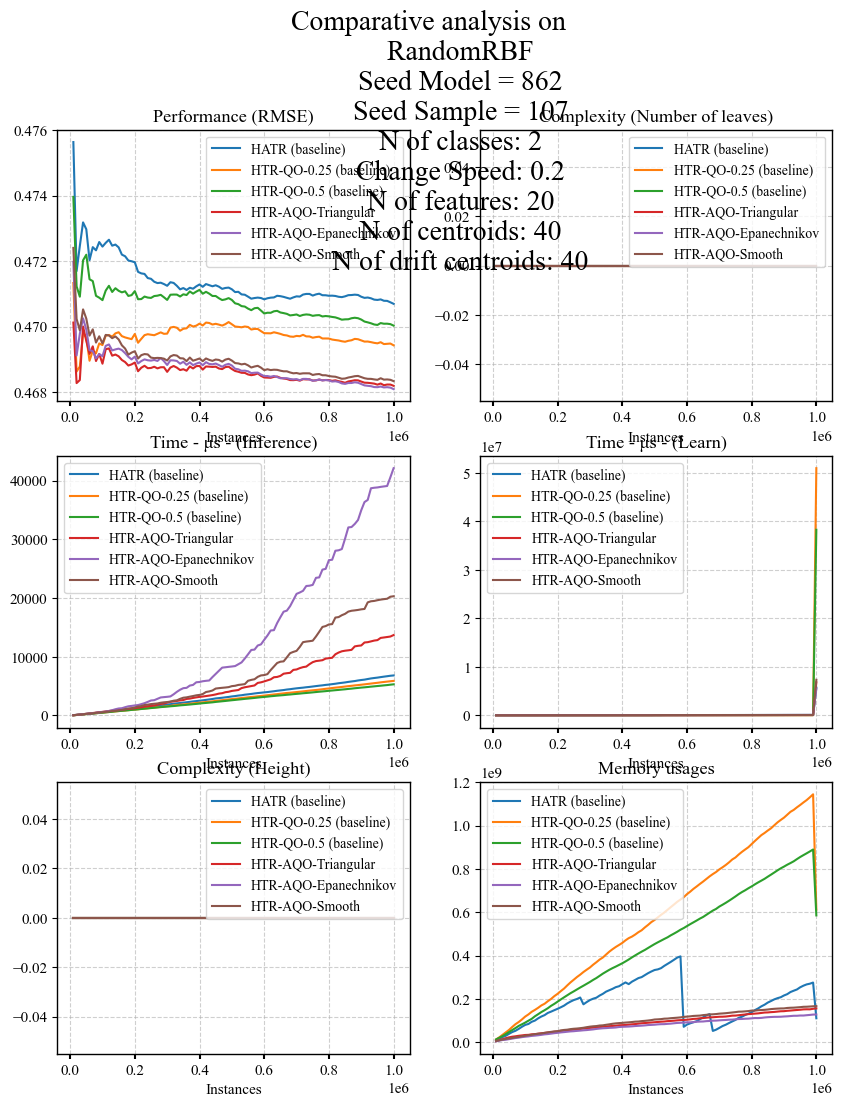

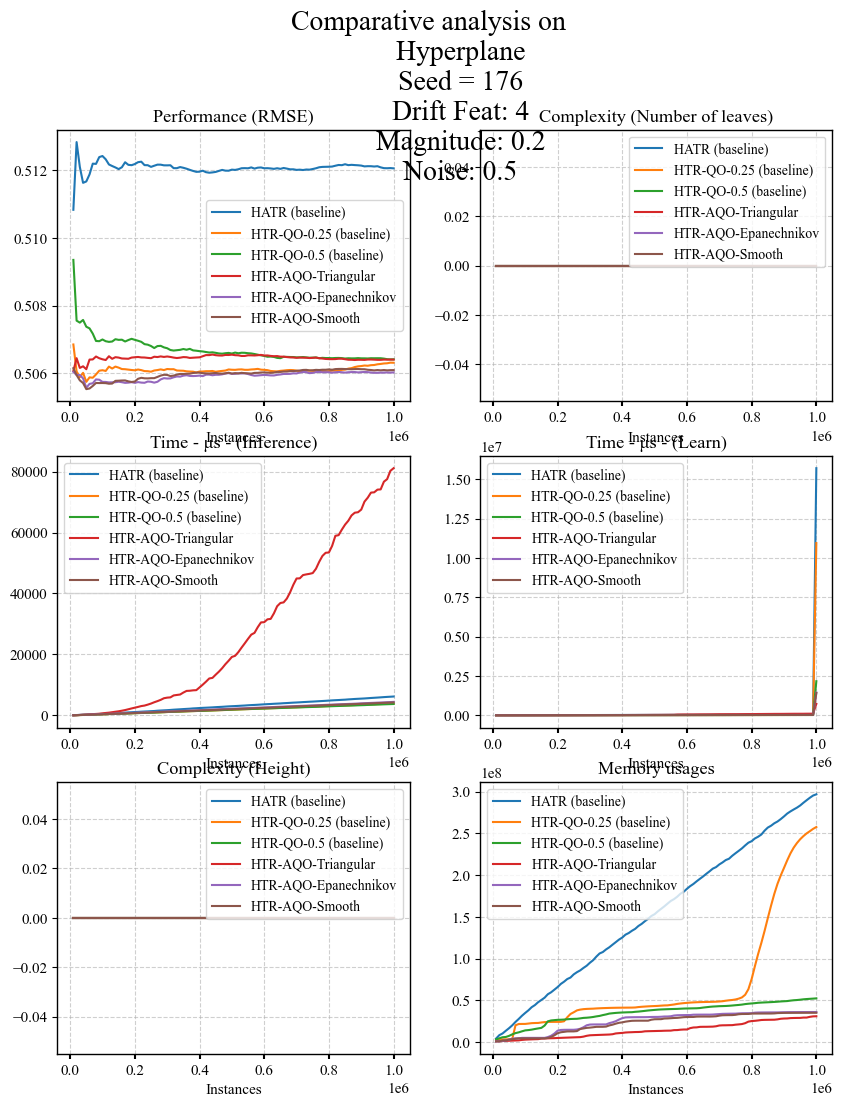

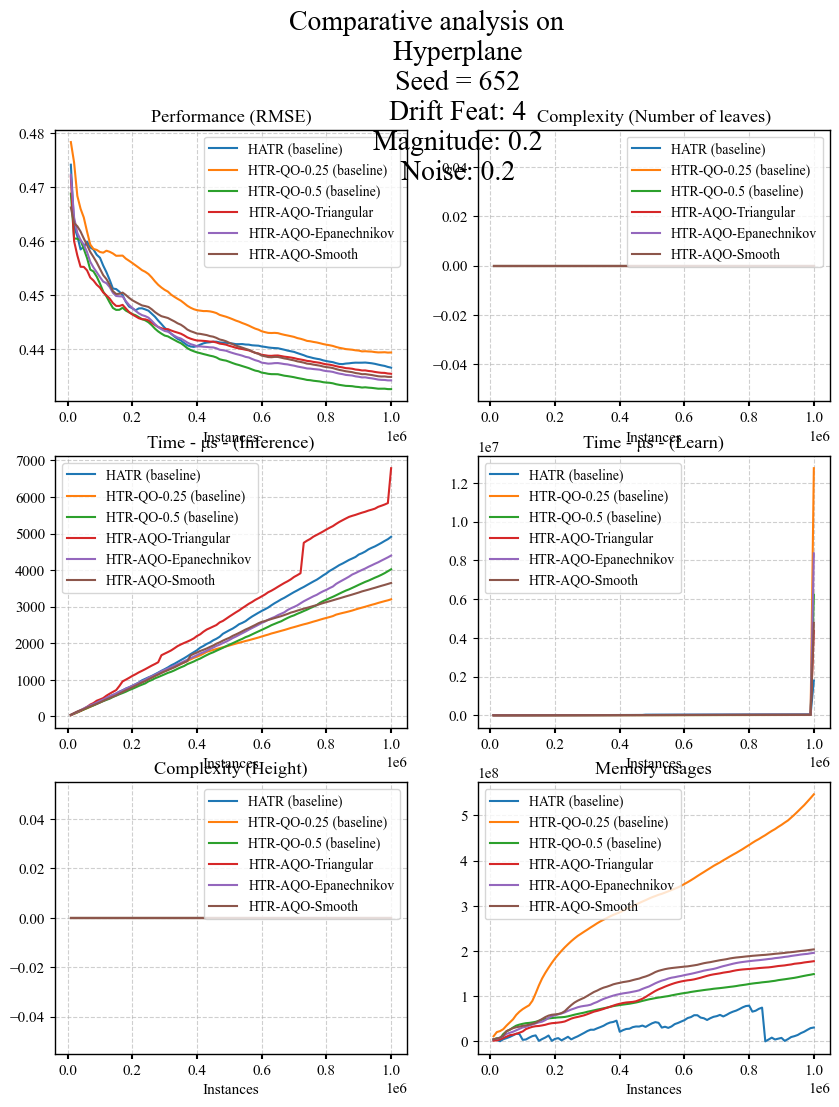

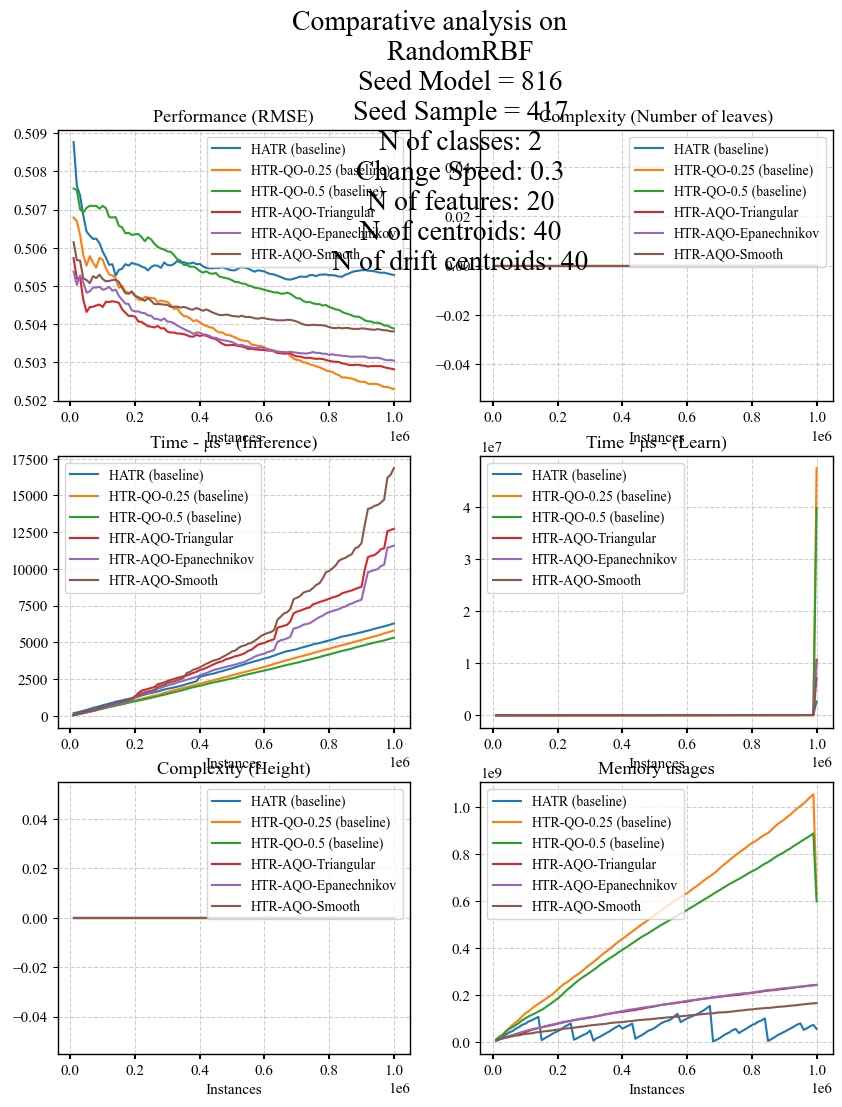

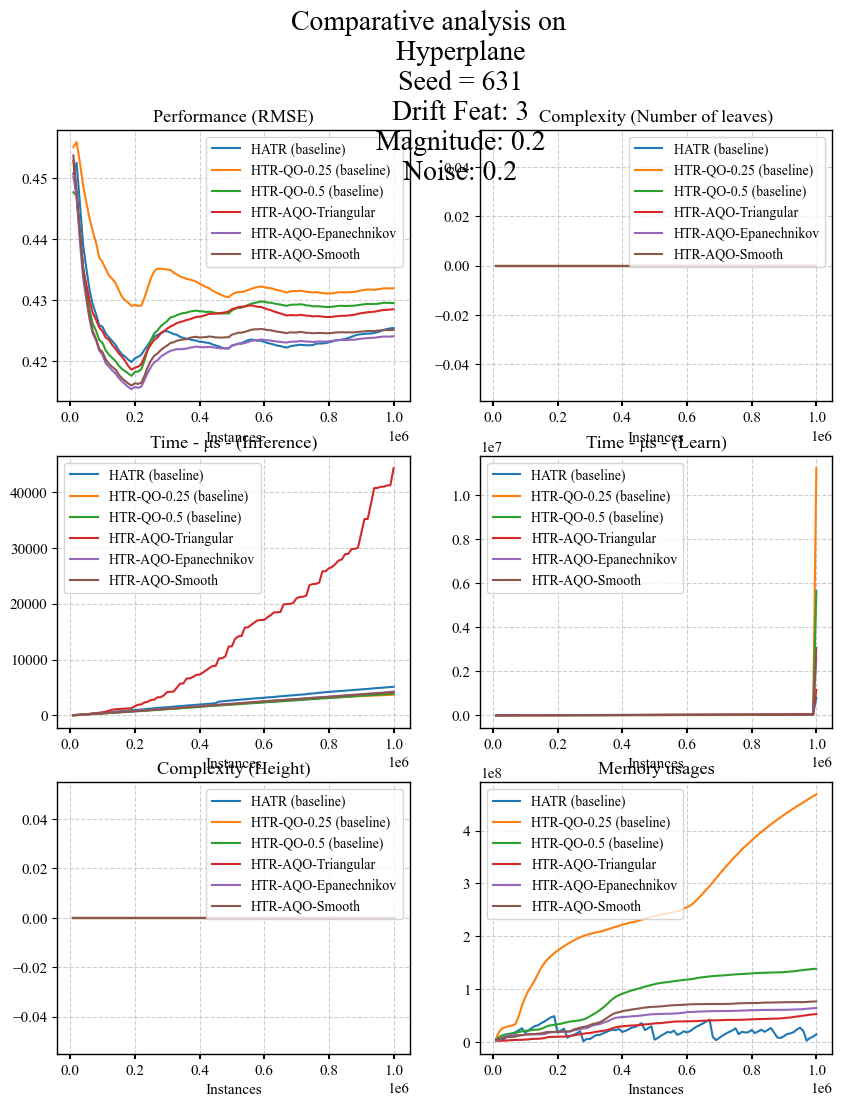

KeyboardInterrupt: 

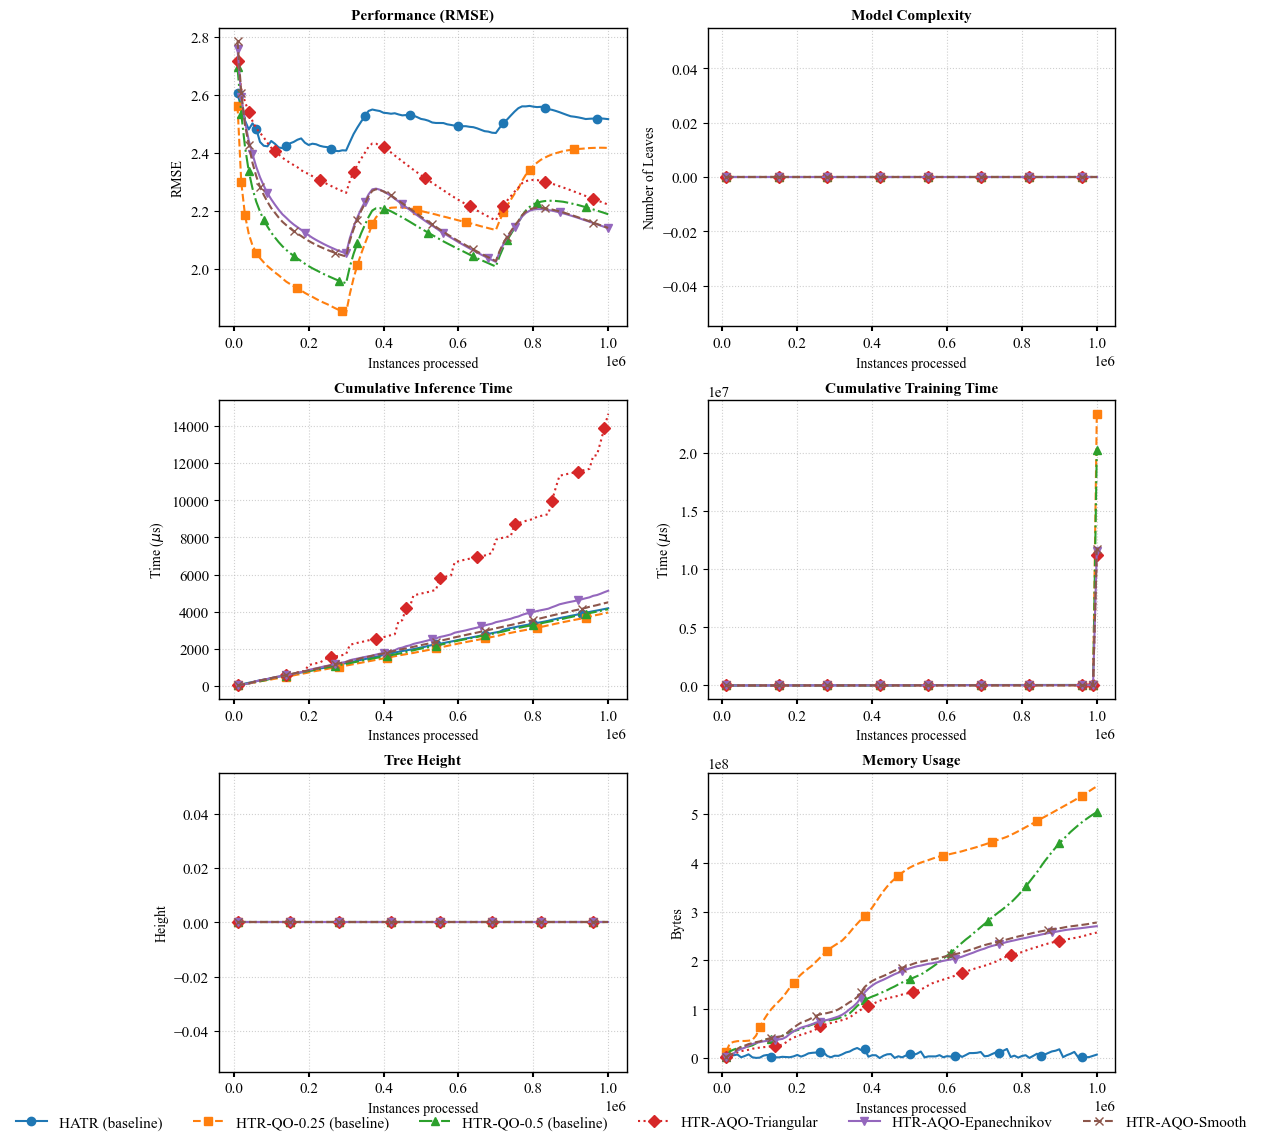

In [10]:
plotter = Plots()
plotter.plot_all(logs)
plotter.export(logs)